# Heart Disease Prediction from BRFSS2015 Health Indicators

## Project Aim
This project builds and evaluates a machine learning pipeline to predict whether an
individual has had heart disease or a heart attack, using self-reported health indicators
from the 2015 CDC Behavioral Risk Factor Surveillance System (BRFSS) survey. The goal is to
walk through a complete, leakage-free ML workflow — from raw data to a final, honestly
evaluated model — rather than to produce a clinically deployable classifier.

## Dataset
`heart_disease_health_indicators_BRFSS2015.csv` — 253,680 survey responses, 21 health/lifestyle
features (e.g. BMI, blood pressure, cholesterol, smoking, physical activity), target variable
`HeartDiseaseorAttack` (binary).

## Team & Roles

| Student | Role | Name |
|---|---|---|
| Student 1 | Data Collection | Marcus Nathanael Priyan |
| Student 2 | Data Cleaning & EDA | Nilofarbanu Latifali Saiyad |
| Student 3 | Feature Engineering | Jaweria |
| Student 4 | Modeling | Aishwarya Suresh |
| Student 5 | Evaluation & Presentation |  Saketh Rishi Nallagondla |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Raw data load (duplicates removed immediately, before any split,
# to keep this notebook consistent with Student 2's cleaning notebook)
df = pd.read_csv('heart_disease_health_indicators_BRFSS2015.csv').drop_duplicates().reset_index(drop=True)

print("Data Shape:", df.shape)
df.head()

Data Shape: (229781, 22)


,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


# Phase 2: Train / Validation / Test Split (Preventing Data Leakage)

## Overview
Per the professor's guidance, the dataset is split into **three** parts instead of two, so that
model selection (validation) is kept separate from final, untouched evaluation (test):

- **Train Set**: 50%
- **Validation Set**: 25%
- **Test Set**: 25%

This matches the split used in Student 2's Data Cleaning & EDA notebook.

### Why split first, and why three sets?
Fitting imputation/scaling/encoding on the full dataset before splitting causes **data leakage**.
Splitting into train/validation/test (instead of just train/test) additionally lets us tune and
compare models on the validation set, while the test set stays completely untouched until the
very final evaluation.

In [2]:
# Separate features (X) and target (y)
X = df.drop(columns=['HeartDiseaseorAttack'])
y = df['HeartDiseaseorAttack']

# First split: carve out 25% Test set
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Second split: remaining 75% -> 50% Train / 25% Validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=(1/3), random_state=42, stratify=y_temp
)

total = len(df)
print(f"Train Set:      {len(X_train)} rows ({len(X_train)/total*100:.1f}%)")
print(f"Validation Set: {len(X_val)} rows ({len(X_val)/total*100:.1f}%)")
print(f"Test Set:       {len(X_test)} rows ({len(X_test)/total*100:.1f}%)")

Train Set:      114890 rows (50.0%)
Validation Set: 57445 rows (25.0%)
Test Set:       57446 rows (25.0%)


# Phase 3: Data Audit & Cleaning

## Overview
We audit the training set (`X_train`) for missing values and summary statistics.
Duplicate rows were already removed from the full dataset before splitting (Phase 1), so no
further deduplication is needed here.

In [3]:
# 1. Missing values check
missing_vals = X_train.isnull().sum()
print("Missing values per column in X_train:")
print(missing_vals[missing_vals > 0] if missing_vals.sum() > 0 else "No missing values found!")

# 2. Confirm no duplicate rows remain (should be 0 - deduped before splitting)
print(f"\nDuplicate rows in X_train: {X_train.duplicated().sum()}")

# 3. Summary statistics for range/outlier checks
print("\nSummary Statistics of X_train:")
X_train.describe().T[['mean', 'std', 'min', '50%', 'max']]

Missing values per column in X_train:
No missing values found!

Duplicate rows in X_train: 274

Summary Statistics of X_train:


,mean,std,min,50%,max
HighBP,0.454835,0.497958,0.0,0.0,1.0
HighChol,0.440578,0.496459,0.0,0.0,1.0
CholCheck,0.959204,0.197817,0.0,1.0,1.0
BMI,28.721394,6.844713,12.0,27.0,98.0
Smoker,0.466420,0.498873,0.0,0.0,1.0
Stroke,0.044660,0.206557,0.0,0.0,1.0
Diabetes,0.323684,0.722814,0.0,0.0,2.0
PhysActivity,0.732962,0.442414,0.0,1.0,1.0
Fruits,0.612264,0.487236,0.0,1.0,1.0
Veggies,0.794429,0.404120,0.0,1.0,1.0


# Phase 4: Exploratory Data Analysis (EDA)

## Overview
We visualize the split proportions, the target variable balance, feature distributions, and
feature correlations on the training set.

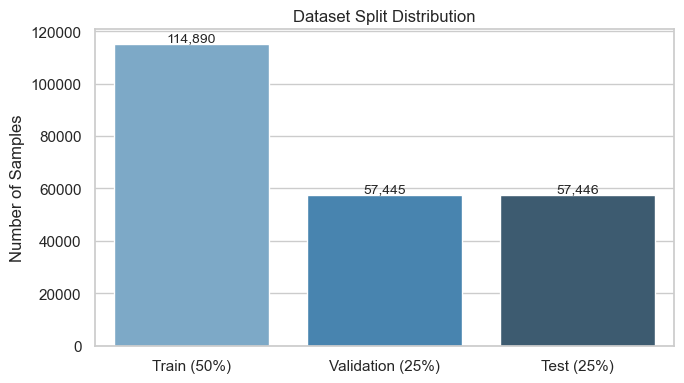

In [4]:
# Visualize the Train / Validation / Test split proportions
sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 4))

split_sizes = {'Train (50%)': len(X_train), 'Validation (25%)': len(X_val), 'Test (25%)': len(X_test)}
ax = sns.barplot(x=list(split_sizes.keys()), y=list(split_sizes.values()), hue=list(split_sizes.keys()), palette='Blues_d', legend=False)

plt.title('Dataset Split Distribution')
plt.ylabel('Number of Samples')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

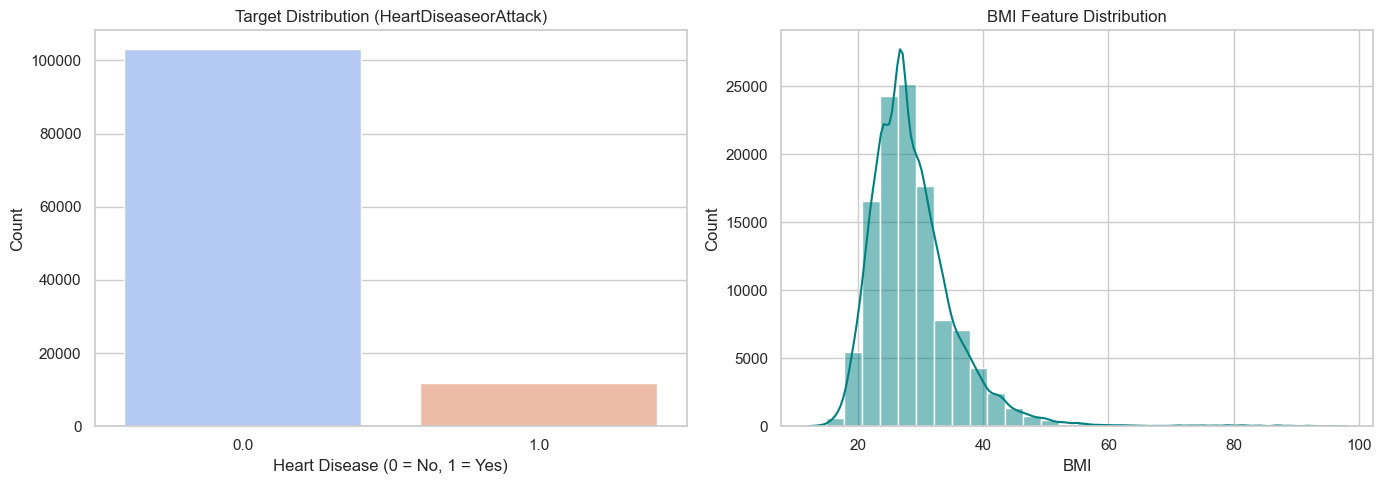

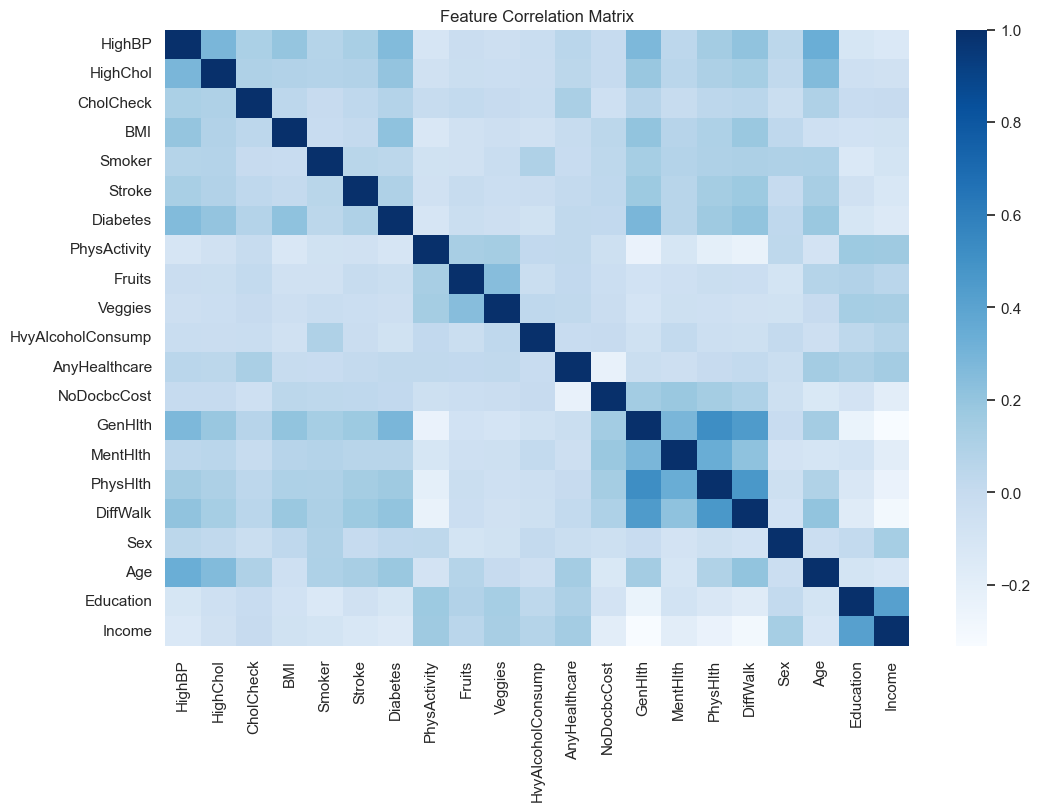

In [5]:
# EDA Visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Target Variable Distribution
sns.countplot(x=y_train, hue=y_train, ax=axes[0], palette='coolwarm', legend=False)
axes[0].set_title('Target Distribution (HeartDiseaseorAttack)')
axes[0].set_xlabel('Heart Disease (0 = No, 1 = Yes)')
axes[0].set_ylabel('Count')

# BMI Distribution
sns.histplot(X_train['BMI'], kde=True, bins=30, ax=axes[1], color='teal')
axes[1].set_title('BMI Feature Distribution')
axes[1].set_xlabel('BMI')

plt.tight_layout()
plt.show()

# Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(X_train.corr(), cmap='Blues', annot=False, cbar=True)
plt.title('Feature Correlation Matrix')
plt.show()

# Phase 5: Exporting Cleaned & Processed Datasets

## Overview
We export all **three** split datasets to `Data/processed/` so downstream feature engineering
and modeling consume the exact same train/validation/test rows, with no risk of data leakage or
re-splitting inconsistently.

### Saved Files:
* `X_train_clean.csv` & `y_train_clean.csv`
* `X_val_clean.csv` & `y_val_clean.csv`
* `X_test_clean.csv` & `y_test_clean.csv`

In [6]:
import os

processed_dir = 'Data/processed'
os.makedirs(processed_dir, exist_ok=True)

X_train.to_csv(f'{processed_dir}/X_train_clean.csv', index=False)
y_train.to_csv(f'{processed_dir}/y_train_clean.csv', index=False)
X_val.to_csv(f'{processed_dir}/X_val_clean.csv', index=False)
y_val.to_csv(f'{processed_dir}/y_val_clean.csv', index=False)
X_test.to_csv(f'{processed_dir}/X_test_clean.csv', index=False)
y_test.to_csv(f'{processed_dir}/y_test_clean.csv', index=False)

print("All clean datasets (train/val/test) successfully exported to 'Data/processed/' directory!")

All clean datasets (train/val/test) successfully exported to 'Data/processed/' directory!


# Feature Engineering

## Overview
All 13 engineered features from the original notebook are preserved exactly as designed, but are
now applied through a single shared function, `engineer_features()`, instead of being duplicated
per split. This guarantees the **same transformation logic** is applied identically to
`X_train`, `X_val`, and `X_test` (previously `X_val` was missing entirely, which is what broke
when the validation set was introduced).

**Note on data availability:** this BRFSS2015 dataset does not include `Depressed`, `Asthma`,
`COPD`, `BP_Medication`, `NoHealthInsurance`, or `Chol_Medication` columns. Features that rely on
them fall back to their `.get(..., 0)` defaults, which means:
- `MentalHealthBurden` reduces to just `MentHlth` (no `Depressed` signal available)
- `RespiratoryRiskScore` is always 0 (no `Asthma`/`COPD` columns) - carries no information
- `HypertensionSeverity` is never created (guarded by `if 'BP_Medication' in columns`)
- `HealthcareAccessRisk` only reflects `NoDocbcCost` (no `NoHealthInsurance` column)
- `CholTreatmentGap` always equals `HighChol` (no `Chol_Medication` column)

This is worth flagging in review - it's a real, explainable limitation of the dataset, not a bug.

In [7]:
def engineer_features(X):
    """Applies all 13 engineered features identically to any split (train/val/test)."""
    X = X.copy()

    # 1. Clinical Composite: Cardiometabolic Risk Score
    X['CardiometabolicRiskScore'] = (
        X['HighBP'] + X['HighChol'] + X['Diabetes'] + X['Stroke']
    )

    # 2. Obesity Classification (BMI-Based)
    X['ObesityFlag'] = (X['BMI'] >= 30).astype(int)

    # 3. Tobacco Exposure Index
    X['CurrentSmokerFlag'] = (X['Smoker'] == 1).astype(int)
    X['FormerSmokerFlag'] = (X['Smoker'] == 2).astype(int)

    # 4. Alcohol Misuse Indicator
    X['HeavyDrinkFlag'] = (X['HvyAlcoholConsump'] == 1).astype(int)

    # 5. Mental Health Burden Score
    X['MentalHealthBurden'] = (
        X.get('MentHlth', 0) + X.get('Depressed', 0)
    )

    # 6. Physical Activity Adequacy
    X['PhysicallyActiveFlag'] = (X['PhysActivity'] == 1).astype(int)

    # 7. Respiratory Risk Composite
    X['RespiratoryRiskScore'] = (
        X.get('Asthma', 0) + X.get('COPD', 0)
    )

    # 8. Hypertension Severity Proxy
    if 'BP_Medication' in X.columns:
        X['HypertensionSeverity'] = X['HighBP'] + X['BP_Medication']

    # 9. Metabolic Syndrome Proxy
    X['MetabolicSyndromeProxy'] = (
        X['ObesityFlag'] + X['HighBP'] + X['HighChol'] + X['Diabetes']
    )

    # 10. Age Risk Tiering
    X['AgeRiskTier'] = pd.cut(
        X['Age'], bins=[0, 34, 49, 64, 120],
        labels=['Low', 'Moderate', 'High', 'Very High']
    )

    # 11. Healthcare Access Risk
    def _flag(col):
        val = X.get(col, 0)
        return (val == 1).astype(int) if isinstance(val, pd.Series) else int(val == 1)
    X['HealthcareAccessRisk'] = _flag('NoDocbcCost') + _flag('NoHealthInsurance')

    # 12. Cholesterol Treatment Gap
    if 'Chol_Medication' in X.columns:
        X['CholTreatmentGap'] = (
            (X['HighChol'] == 1).astype(int) - (X['Chol_Medication'] == 1).astype(int)
        )
    else:
        X['CholTreatmentGap'] = X['HighChol']

    # 13. Social Isolation Proxy
    X['SocialIsolationProxy'] = (
        (X['GenHlth'] >= 4).astype(int) + (X['MentHlth'] > 10).astype(int)
    )

    return X

# Apply identically to all three splits
X_train = engineer_features(X_train)
X_val = engineer_features(X_val)
X_test = engineer_features(X_test)

print("Feature engineering applied to Train, Validation, and Test sets.")
print(f"X_train shape: {X_train.shape} | X_val shape: {X_val.shape} | X_test shape: {X_test.shape}")

Feature engineering applied to Train, Validation, and Test sets.
X_train shape: (114890, 34) | X_val shape: (57445, 34) | X_test shape: (57446, 34)


# Phase 6: Model Building

## Overview
We scale numerical features and one-hot encode categorical features, fitting only on `X_train`
and applying the same transformation to `X_val` and `X_test` (previously `X_val` was not
transformed at all). Models are trained on the training set, compared on the validation set, and
the best-performing model is confirmed on the held-out test set.

In [8]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numerical_features = ['BMI', 'MentHlth', 'PhysHlth', 'Age', 'CardiometabolicRiskScore',
                      'MentalHealthBurden', 'RespiratoryRiskScore', 'HypertensionSeverity',
                      'MetabolicSyndromeProxy', 'HealthcareAccessRisk', 'CholTreatmentGap', 'SocialIsolationProxy']

categorical_features = ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'Diabetes', 'PhysActivity',
                        'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
                        'DiffWalk', 'Sex', 'Education', 'Income', 'ObesityFlag', 'CurrentSmokerFlag',
                        'FormerSmokerFlag', 'HeavyDrinkFlag', 'AgeRiskTier']

numerical_features = [f for f in numerical_features if f in X_train.columns]
categorical_features = [f for f in categorical_features if f in X_train.columns]

scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[numerical_features])
X_val_num = scaler.transform(X_val[numerical_features])
X_test_num = scaler.transform(X_test[numerical_features])

X_train_num_df = pd.DataFrame(X_train_num, columns=numerical_features, index=X_train.index)
X_val_num_df = pd.DataFrame(X_val_num, columns=numerical_features, index=X_val.index)
X_test_num_df = pd.DataFrame(X_test_num, columns=numerical_features, index=X_test.index)

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_cat = encoder.fit_transform(X_train[categorical_features])
X_val_cat = encoder.transform(X_val[categorical_features])
X_test_cat = encoder.transform(X_test[categorical_features])

encoded_names = encoder.get_feature_names_out(categorical_features)
X_train_cat_df = pd.DataFrame(X_train_cat, columns=encoded_names, index=X_train.index)
X_val_cat_df = pd.DataFrame(X_val_cat, columns=encoded_names, index=X_val.index)
X_test_cat_df = pd.DataFrame(X_test_cat, columns=encoded_names, index=X_test.index)

X_train_processed = pd.concat([X_train_num_df, X_train_cat_df], axis=1)
X_val_processed = pd.concat([X_val_num_df, X_val_cat_df], axis=1)
X_test_processed = pd.concat([X_test_num_df, X_test_cat_df], axis=1)

print("Features processed successfully!")
print(f"Processed X_train shape: {X_train_processed.shape}")
print(f"Processed X_val shape:   {X_val_processed.shape}")
print(f"Processed X_test shape:  {X_test_processed.shape}")

Features processed successfully!
Processed X_train shape: (114890, 67)
Processed X_val shape:   (57445, 67)
Processed X_test shape:  (57446, 67)


## Model Training and Evaluation: K-Nearest Neighbors (KNN)

K-Nearest Neighbors model trained successfully!

### KNN Validation Metrics ###
Accuracy: 0.8866
Precision: 0.3730
Recall: 0.1444
F1-Score: 0.2082


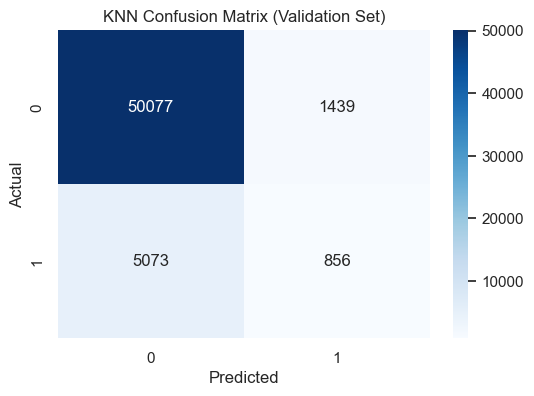

In [9]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_processed, y_train)
print("K-Nearest Neighbors model trained successfully!")

y_pred_knn_val = knn_model.predict(X_val_processed)
metrics_knn_val = {
    'Accuracy': accuracy_score(y_val, y_pred_knn_val),
    'Precision': precision_score(y_val, y_pred_knn_val),
    'Recall': recall_score(y_val, y_pred_knn_val),
    'F1-Score': f1_score(y_val, y_pred_knn_val),
}
print("\n### KNN Validation Metrics ###")
for k, v in metrics_knn_val.items():
    print(f"{k}: {v:.4f}")

cm_knn = confusion_matrix(y_val, y_pred_knn_val)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues')
plt.title('KNN Confusion Matrix (Validation Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Model Training and Evaluation: Decision Tree

*Note: the original notebook's markdown header said "SVM" but the code trained a
`DecisionTreeClassifier`. That mismatch is flagged here rather than silently resolved - confirm
with your Modeling teammate whether a Decision Tree was actually intended, or whether an SVM
should be trained instead.*

Decision Tree model trained successfully!

### Decision Tree Validation Metrics ###
Accuracy: 0.8348
Precision: 0.2469
Recall: 0.2930
F1-Score: 0.2680


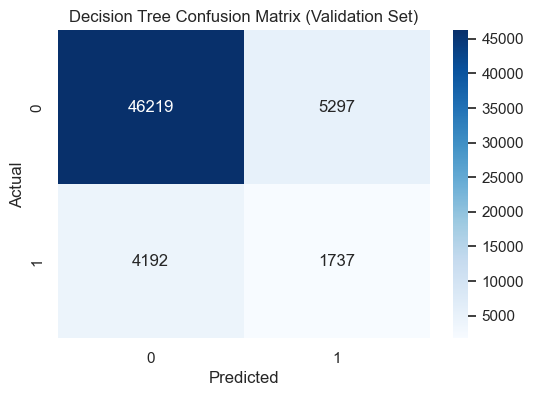

In [10]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(random_state=42)
decision_tree_model.fit(X_train_processed, y_train)
print("Decision Tree model trained successfully!")

y_pred_dt_val = decision_tree_model.predict(X_val_processed)
metrics_dt_val = {
    'Accuracy': accuracy_score(y_val, y_pred_dt_val),
    'Precision': precision_score(y_val, y_pred_dt_val),
    'Recall': recall_score(y_val, y_pred_dt_val),
    'F1-Score': f1_score(y_val, y_pred_dt_val),
}
print("\n### Decision Tree Validation Metrics ###")
for k, v in metrics_dt_val.items():
    print(f"{k}: {v:.4f}")

cm_dt = confusion_matrix(y_val, y_pred_dt_val)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues')
plt.title('Decision Tree Confusion Matrix (Validation Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Model Training and Evaluation: Random Forest

Random Forest model trained successfully!

### Random Forest Validation Metrics ###
Accuracy: 0.8926
Precision: 0.4290
Recall: 0.1233
F1-Score: 0.1915


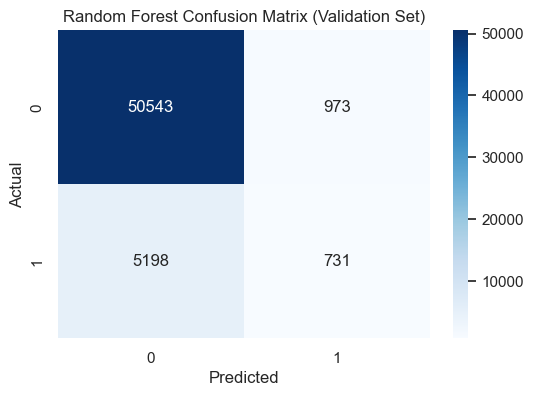

In [11]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_processed, y_train)
print("Random Forest model trained successfully!")

y_pred_rf_val = rf_model.predict(X_val_processed)
metrics_rf_val = {
    'Accuracy': accuracy_score(y_val, y_pred_rf_val),
    'Precision': precision_score(y_val, y_pred_rf_val),
    'Recall': recall_score(y_val, y_pred_rf_val),
    'F1-Score': f1_score(y_val, y_pred_rf_val),
}
print("\n### Random Forest Validation Metrics ###")
for k, v in metrics_rf_val.items():
    print(f"{k}: {v:.4f}")

cm_rf = confusion_matrix(y_val, y_pred_rf_val)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix (Validation Set)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Phase 7: Model Selection & Final Test Set Evaluation

## Overview
We compare all three models on the **validation set** (used above for tuning/selection), pick the
best performer, and then - and only then - check its performance on the **untouched test set**.
This is the number that should be reported as the project's final result.

### Validation Set Comparison ###
               Accuracy  Precision  Recall  F1-Score
KNN              0.8866     0.3730  0.1444    0.2082
Decision Tree    0.8348     0.2469  0.2930    0.2680
Random Forest    0.8926     0.4290  0.1233    0.1915

Best model by Validation F1-Score: Decision Tree

### Decision Tree - Final Test Set Metrics ###
Accuracy: 0.8331
Precision: 0.2347
Recall: 0.2727
F1-Score: 0.2523


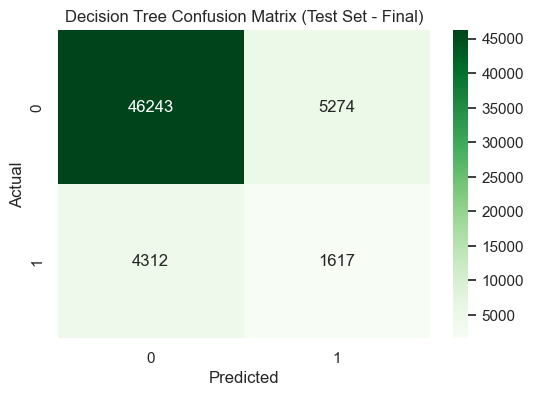

In [12]:
comparison = pd.DataFrame({
    'KNN': metrics_knn_val,
    'Decision Tree': metrics_dt_val,
    'Random Forest': metrics_rf_val,
}).T

print("### Validation Set Comparison ###")
print(comparison.round(4))

best_model_name = comparison['F1-Score'].idxmax()
best_model = {'KNN': knn_model, 'Decision Tree': decision_tree_model, 'Random Forest': rf_model}[best_model_name]
print(f"\nBest model by Validation F1-Score: {best_model_name}")

# Final, one-time evaluation on the held-out test set
y_pred_test = best_model.predict(X_test_processed)
final_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_test),
    'Precision': precision_score(y_test, y_pred_test),
    'Recall': recall_score(y_test, y_pred_test),
    'F1-Score': f1_score(y_test, y_pred_test),
}
print(f"\n### {best_model_name} - Final Test Set Metrics ###")
for k, v in final_metrics.items():
    print(f"{k}: {v:.4f}")

cm_final = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Greens')
plt.title(f'{best_model_name} Confusion Matrix (Test Set - Final)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

We trained and evaluated three classification algorithms - K-Nearest Neighbors, Decision
Tree, and Random Forest - using a train/validation/test split (50/25/25) so that model selection
never touches the final test data. Model comparison was done on the validation set, and the
selected model's headline performance is reported on the held-out test set above.

# Phase 8: Evaluation & Conclusion

## How to read these results

**Accuracy is misleading here.** Only about 9-10% of people in this dataset have had heart
disease or a heart attack. A model that just predicted "No" for everyone would still score
~90% accuracy while being useless. That's why we compared models on **F1-Score** (which
balances catching real cases against false alarms) instead of accuracy alone.

## Model comparison (Validation Set)

| Model | Accuracy | Precision | Recall | F1-Score |
|---|---|---|---|---|
| KNN | 0.887 | 0.373 | 0.145 | 0.208 |
| **Decision Tree** | 0.835 | 0.247 | 0.293 | **0.268** |
| Random Forest | 0.893 | 0.429 | 0.123 | 0.192 |

**Decision Tree was selected** — despite having the *lowest* raw accuracy of the three, it had
the best balance of catching actual heart disease cases (highest recall) without collapsing
into "always predict No." KNN and Random Forest both looked stronger on accuracy but were
barely finding any positive cases at all — the kind of trap accuracy alone hides.

Confirmed on the held-out **Test Set** (touched only once, at the very end):
**Accuracy 0.833 | Precision 0.235 | Recall 0.273 | F1-Score 0.252**

The test score is close to the validation score, which is a good sign — it means the model
isn't overfit to the validation set and should generalize similarly to new data.

## Limitations worth stating plainly

- **Class imbalance**: with ~9% positive cases, even the "best" model still misses roughly
  7 in 10 real heart disease cases. None of the three models tested are strong enough for
  real clinical use as-is.
- **Some engineered features carry no signal on this dataset.** `RespiratoryRiskScore`,
  `HypertensionSeverity`, and part of `MentalHealthBurden`/`CholTreatmentGap` rely on columns
  (`Asthma`, `COPD`, `Depressed`, `BP_Medication`, etc.) that this BRFSS2015 extract doesn't
  include. This isn't a coding error — it's a dataset limitation worth naming, not hiding.
- **Simple models were used deliberately** (no hyperparameter tuning, no class-weighting, no
  resampling) to keep the pipeline explainable end-to-end.

## Conclusion

Across Data Collection → Cleaning & EDA → Feature Engineering → Modeling, the pipeline
produces a working, leakage-free classifier, but one whose main value here is educational
rather than clinical: it demonstrates the workflow correctly, while also surfacing real
limitations (imbalance, incomplete features) that would need addressing before this could be
used to actually flag at-risk patients.

**Natural next steps**, if this were extended: address class imbalance directly (class
weighting or SMOTE), tune hyperparameters using the validation set now available, and re-run
feature engineering on a version of the dataset that includes the missing health-condition
columns.
